## **Causal Transformer with pretrained Fasttext and relative position embedding**

#### **Installing dependencies**

In [24]:
!pip install gensim tqdm

#### **Importing libraries**

In [ ]:
import pandas as pd
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import gensim.downloader as api
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.utils.class_weight import compute_class_weight
import time
from sklearn.metrics import auc as sk_auc
from sklearn.model_selection import StratifiedKFold

#### **Loading data into dataframe**

In [31]:
csv_file_path = "../data/preprocessed/"
X_train_df = pd.read_csv(csv_file_path + "X_train.csv")
X_val_df = pd.read_csv(csv_file_path + "X_val.csv")
X_test_df = pd.read_csv(csv_file_path + "X_test.csv")

y_train_df = pd.read_csv(csv_file_path + "y_train.csv")
y_val_df = pd.read_csv(csv_file_path + "y_val.csv")
y_test_df = pd.read_csv(csv_file_path + "y_test.csv")

#### **Loading label encoder for classes**

In [32]:
with open("../Models/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

c:\Users\User\anaconda3\envs\health_risk_model\lib\site-packages\sklearn\base.py:318: UserWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


#### **Helper function to get performance metrics, confusion matrix and ROC plot**

In [33]:
def plot_confusion_matrix(y_true, y_pred, labels=None):
    conf = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    xticks = labels if labels is not None else ""
    yticks = labels if labels is not None else ""
    sns.heatmap(conf, annot=True, fmt='g', cmap='Blues', cbar=False,
                xticklabels=xticks, yticklabels=yticks)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

def evaluate_model(y_true, y_pred, model_name="Model", y_proba=None, labels=None):
    print(f"\nPerformance Metrics for {model_name}:")
    print(f"Accuracy     : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision    : {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"Recall       : {recall_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1 Score     : {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels))
    plot_confusion_matrix(y_true, y_pred, labels=labels)

def plot_auc_curve(y_test, y_prob, class_labels=None, calledFrom='main'):
    from sklearn.preprocessing import label_binarize

    if len(np.unique(y_test)) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1] if y_prob.ndim > 1 else y_prob)
        roc_auc = roc_auc_score(y_test, y_prob[:, 1] if y_prob.ndim > 1 else y_prob)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc='lower right')
        plt.grid()
        plt.show()
    else:
        y_test_bin = label_binarize(y_test, classes=np.arange(y_prob.shape[1]))
        fpr, tpr, roc_auc = {}, {}, {}
        for i in range(y_prob.shape[1]):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            roc_auc[i] = sk_auc(fpr[i], tpr[i])  # <-- Use sk_auc here!
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(roc_auc))]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(len(roc_auc)):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= len(roc_auc)
        plt.figure(figsize=(8, 6))
        from itertools import cycle
        colors = cycle(['red', 'blue', 'green', 'purple', 'orange', 'brown', 'cyan'])
        for i, color in zip(range(len(roc_auc)), colors):
            label = f'Class {class_labels[i]}' if class_labels is not None else f'Class {i}'
            plt.plot(fpr[i], tpr[i], color=color, label=f'{label} (AUC = {roc_auc[i]:.2f})')
        plt.plot(all_fpr, mean_tpr, color='black', linestyle='--',
                 label=f'Macro-Average (AUC = {sk_auc(all_fpr, mean_tpr):.2f})')
        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Multiclass ROC Curve')
        plt.legend(loc='lower right')
        plt.grid()
        plt.show()
        roc_auc_macro = sk_auc(all_fpr, mean_tpr)
    if calledFrom == 'tuning':
        return roc_auc_macro

#### **Tokenzing the training dataframe**

In [34]:
max_vocab_size = 10000
max_len = 50
embed_dim  = 100

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token="<UNK>") 
tokenizer.fit_on_texts(X_train_df['clean_tweet'])

In [35]:
X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_df['clean_tweet']), maxlen=max_len, padding='post')
X_val = pad_sequences(tokenizer.texts_to_sequences(X_val_df['clean_tweet']), maxlen=max_len, padding='post')
X_test = pad_sequences(tokenizer.texts_to_sequences(X_test_df['clean_tweet']), maxlen=max_len, padding='post')

In [36]:
y_train = to_categorical(le.transform(y_train_df['sentiment_consolidated']))
y_val = to_categorical(le.transform(y_val_df['sentiment_consolidated']))
y_test = to_categorical(le.transform(y_test_df['sentiment_consolidated']))
num_classes = y_train.shape[1]

#### **Checking for class imbalance**

In [37]:
def print_class_percentages(df, label_col="sentiment_consolidated", split_name=""):
    counts = df[label_col].value_counts()
    total = counts.sum()
    print(f"{split_name} set class distribution (percentages):")
    for label, count in counts.items():
        print(f"  {label:<10}: {count:>7} ({100*count/total:6.2f}%)")
    print()

print_class_percentages(y_train_df, "sentiment_consolidated", "Train")
print_class_percentages(y_val_df, "sentiment_consolidated", "Validation")
print_class_percentages(y_test_df, "sentiment_consolidated", "Test")


Train set class distribution (percentages):
  positive  :  178475 ( 33.33%)
  negative  :  178475 ( 33.33%)
  neutral   :  178475 ( 33.33%)

Validation set class distribution (percentages):
  positive  :   59492 ( 67.43%)
  negative  :   15314 ( 17.36%)
  neutral   :   13427 ( 15.22%)

Test set class distribution (percentages):
  positive  :   59492 ( 67.43%)
  negative  :   15314 ( 17.36%)
  neutral   :   13427 ( 15.22%)



There is no class imbalance in the training data set and all the classes have equal number of data points.

#### **Loading Fasttext vectors**

In [38]:
print("Loading FastText vectors")
ft = api.load("fasttext-wiki-news-subwords-300")

vocab_size = min(20000, len(tokenizer.word_index) + 1)
embedding_matrix = np.zeros((vocab_size, embed_dim))
for word, i in tqdm(tokenizer.word_index.items()):
    if i >= vocab_size:
        continue
    if word in ft:
        embedding_matrix[i] = ft[word][:embed_dim]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embed_dim,))

Loading FastText vectors


100%|██████████| 93128/93128 [00:00<00:00, 423246.20it/s]


#### **Defining the relative position embedding**

In [39]:
class RelativePositionEmbedding(layers.Layer):
    def __init__(self, max_len, embed_dim):
        super().__init__()
        self.max_len = max_len
        self.rel_pos_emb = self.add_weight(
            shape=(2 * max_len - 1, embed_dim),
            initializer="random_normal",
            trainable=True,
            name="rel_pos_emb"
        )

    def call(self, seq_len):
        range_vec = tf.range(seq_len)
        rel_pos = tf.expand_dims(range_vec, 0) - tf.expand_dims(range_vec, 1) + self.max_len - 1
        rel_pos = tf.clip_by_value(rel_pos, 0, 2 * self.max_len - 2)
        return tf.gather(self.rel_pos_emb, rel_pos)

#### **Defining the transformer block (Causal Transformer MutliHead Attention with Relative postition embedding)**

In [40]:
class CausalMHAWithRelPos(layers.Layer):
    def __init__(self, embed_dim, num_heads, max_len, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.rel_pos = RelativePositionEmbedding(max_len, embed_dim)

    def call(self, x, training=None):
        seq_len = tf.shape(x)[1]
        rel_emb = self.rel_pos(seq_len)
        rel_emb = tf.expand_dims(rel_emb, 0)  # (1, seq_len, seq_len, emb)
        bias = tf.reduce_mean(rel_emb, axis=2)  # (1, seq_len, emb)
        x = x + bias

        mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        mask = tf.cast(mask, dtype=tf.bool)
        attn_out = self.mha(x, x, attention_mask=mask)
        return attn_out


#### **Building the transformer block**

In [41]:
def build_causal_transformer(
    vocab_size, embed_dim, max_len, num_heads, ff_dim, num_classes, embedding_matrix, num_layers=2, dropout=0.2
):
    inputs = keras.Input(shape=(max_len,), dtype=tf.int32)
    embedding = layers.Embedding(
        vocab_size,
        embed_dim,
        weights=[embedding_matrix],
        trainable=True,
        mask_zero=True,
        name="fasttext_embedding"
    )(inputs)

    x = embedding
    for _ in range(num_layers):
        attn = CausalMHAWithRelPos(embed_dim, num_heads, max_len)(x)
        x = layers.Add()([x, attn])
        x = layers.LayerNormalization()(x)
        ff = layers.Dense(ff_dim, activation="relu")(x)
        x = layers.Add()([x, ff])
        x = layers.LayerNormalization()(x)
        x = layers.Dropout(dropout)(x)

    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    return model

model = build_causal_transformer(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    max_len=max_len,
    num_heads=4,
    ff_dim=embed_dim,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix,
    num_layers=2,
    dropout=0.2,
)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


c:\Users\User\anaconda3\envs\health_risk_model\lib\site-packages\keras\src\layers\layer.py:932: UserWarning: Layer 'causal_mha_with_rel_pos' (of type CausalMHAWithRelPos) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fasttext_embedding  │ (None, 50, 100)   │  2,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_mha_with_re… │ (None, 50, 100)   │    171,200 │ fasttext_embeddi… │
│ (CausalMHAWithRelP… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 100)   │          0 │ fasttext_embeddi… │
│                     │                   │            │ causal_mha_with_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 50, 100)   │        200 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 100)   │     10,100 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50, 100)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 100)   │        200 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 50, 100)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ causal_mha_with_re… │ (None, 50, 100)   │    171,200 │ dropout_5[0][0]   │
│ (CausalMHAWithRelP… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 50, 100)   │          0 │ dropout_5[0][0],  │
│                     │                   │            │ causal_mha_with_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 100)   │        200 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50, 100)   │     10,100 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 50, 100)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 100)   │        200 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 50, 100)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ dropout_7[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        303 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 2,363,703 (9.02 MB)

 Trainable params: 2,363,703 (9.02 MB)

 Non-trainable params: 0 (0.00 B)

#### **Assigning class weights**

In [42]:
y_train_int = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 1.0, 1: 1.0, 2: 1.0}


#### **Fitting the model**

In [43]:
start_time = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=5,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    class_weight=class_weight_dict
)
end_time = time.time()

Epoch 1/5


c:\Users\User\anaconda3\envs\health_risk_model\lib\site-packages\keras\src\layers\layer.py:932: UserWarning: Layer 'causal_mha_with_rel_pos' (of type CausalMHAWithRelPos) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


4184/4184 ━━━━━━━━━━━━━━━━━━━━ 1229s 292ms/step - accuracy: 0.7494 - loss: 0.6010 - val_accuracy: 0.8586 - val_loss: 0.3813
Epoch 2/5
4184/4184 ━━━━━━━━━━━━━━━━━━━━ 1195s 286ms/step - accuracy: 0.8763 - loss: 0.3327 - val_accuracy: 0.8524 - val_loss: 0.4220
Epoch 3/5
4184/4184 ━━━━━━━━━━━━━━━━━━━━ 1253s 300ms/step - accuracy: 0.9114 - loss: 0.2463 - val_accuracy: 0.8554 - val_loss: 0.4519


#### **Training time for the model**

In [44]:
training_time = end_time - start_time
min, sec = divmod(training_time, 60)
hr, min = divmod(min, 60)
print(f"Training Time: {hr:.0f} hour {min:.0f} min {sec:.2f} sec")

Training Time: 1 hour 1 min 18.13 sec


#### Saving the model file

In [45]:
model.save('../Models/causal_tf_fasttext_model.h5')
import pickle
with open('../Models/ctfft_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

#### Loading the model from file

In [26]:
model = keras.models.load_model('../Models/causal_tf_fasttext_model.h5', custom_objects={
    'RelativePositionEmbedding': RelativePositionEmbedding,
    'CausalMHAWithRelPos': CausalMHAWithRelPos
})

with open('../Models/ctfft_history.pkl', 'rb') as f:
    history = pickle.load(f)

c:\Users\User\anaconda3\envs\health_risk_model\lib\site-packages\keras\src\layers\layer.py:932: UserWarning: Layer 'causal_mha_with_rel_pos_2' (of type CausalMHAWithRelPos) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


#### **Predicting on Training set**

In [46]:
train_probs = model.predict(X_train)
y_train_pred = np.argmax(train_probs, axis=1)
y_train_true = np.argmax(y_train, axis=1)

16733/16733 ━━━━━━━━━━━━━━━━━━━━ 479s 29ms/step


####  **Predicting on Validation set**

In [ ]:
val_probs   = model.predict(X_val)
y_val_pred   = np.argmax(val_probs, axis=1)
y_val_true   = np.argmax(y_val, axis=1)

2758/2758 ━━━━━━━━━━━━━━━━━━━━ 70s 25ms/step


#### **Predicting on Testing set**

In [48]:
test_probs  = model.predict(X_test)
y_test_pred  = np.argmax(test_probs, axis=1)
y_test_true  = np.argmax(y_test, axis=1)

2758/2758 ━━━━━━━━━━━━━━━━━━━━ 62s 22ms/step


In [ ]:
labels = list(le.classes_)

#### **Performance metrics, Confusion matrix and ROC curve for Training set**


Performance Metrics for Causal Transformer (Train):
Accuracy     : 0.8773
Precision    : 0.8777
Recall       : 0.8773
F1 Score     : 0.8772

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.87      0.89    178475
     neutral       0.85      0.85      0.85    178475
    positive       0.87      0.91      0.89    178475

    accuracy                           0.88    535425
   macro avg       0.88      0.88      0.88    535425
weighted avg       0.88      0.88      0.88    535425



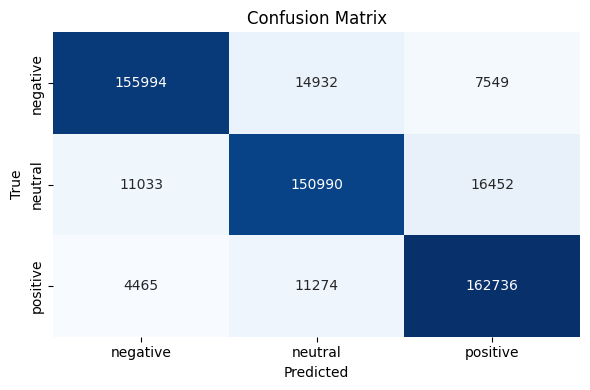

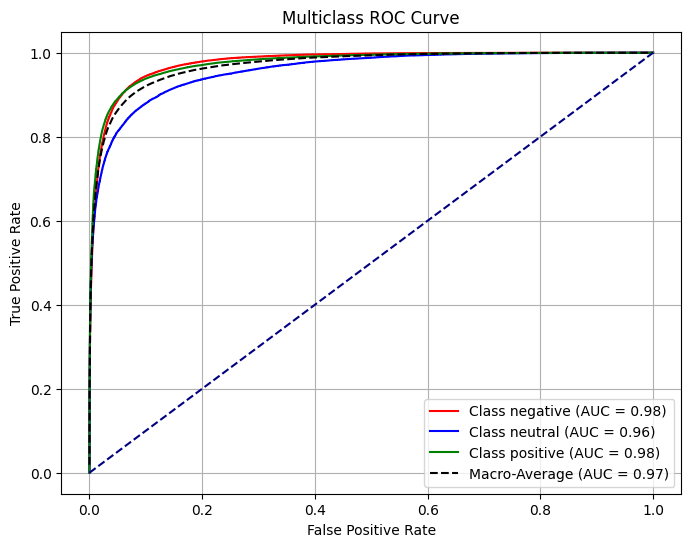

In [50]:
evaluate_model(y_train_true, y_train_pred, model_name="Causal Transformer (Train)", y_proba=train_probs, labels=labels)
plot_auc_curve(y_train_true, train_probs, class_labels=labels)

#### **Performance metrics, Confusion matrix and ROC curve for Validation set**


Performance Metrics for Causal Transformer (Validation):
Accuracy     : 0.8586
Precision    : 0.8709
Recall       : 0.8586
F1 Score     : 0.8631

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.79      0.79     15314
     neutral       0.61      0.75      0.67     13427
    positive       0.95      0.90      0.93     59492

    accuracy                           0.86     88233
   macro avg       0.78      0.81      0.80     88233
weighted avg       0.87      0.86      0.86     88233



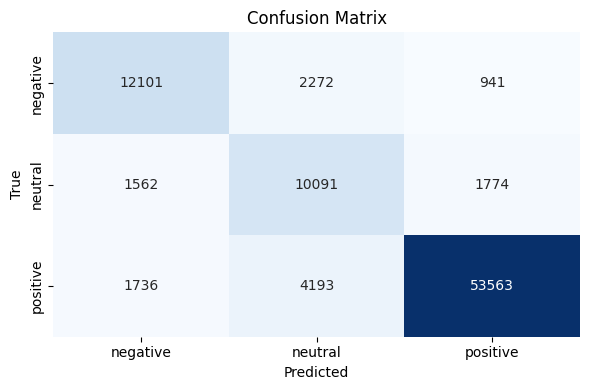

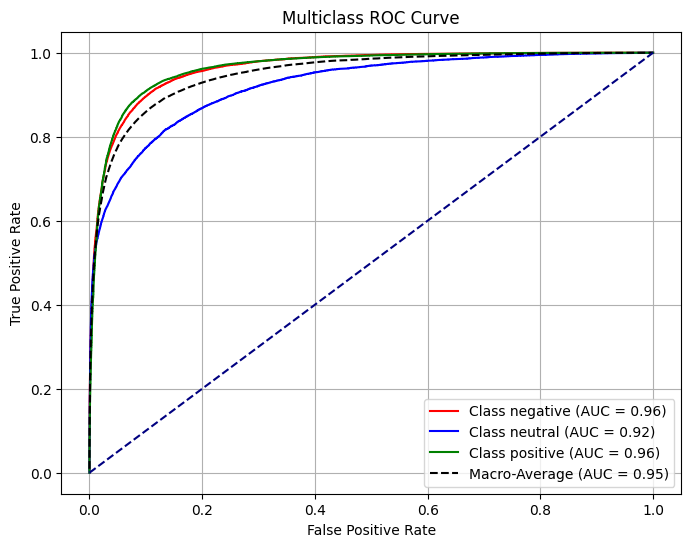

In [51]:
evaluate_model(y_val_true, y_val_pred, model_name="Causal Transformer (Validation)", y_proba=val_probs, labels=labels)
plot_auc_curve(y_val_true, val_probs, class_labels=labels)

#### **Performance metrics, Confusion matrix and ROC curve for Testing set**


Performance Metrics for Causal Transformer (Test):
Accuracy     : 0.8581
Precision    : 0.8701
Recall       : 0.8581
F1 Score     : 0.8625

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.79      0.79     15314
     neutral       0.61      0.75      0.67     13427
    positive       0.95      0.90      0.93     59492

    accuracy                           0.86     88233
   macro avg       0.78      0.81      0.79     88233
weighted avg       0.87      0.86      0.86     88233



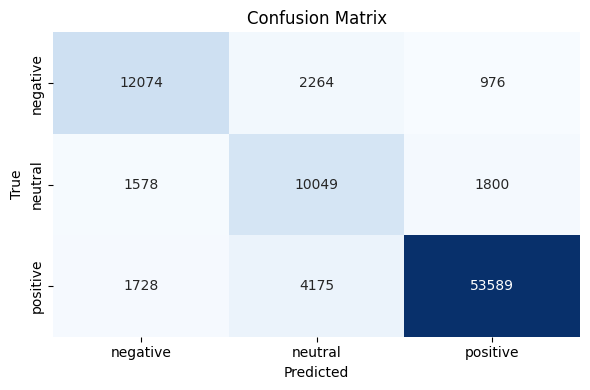

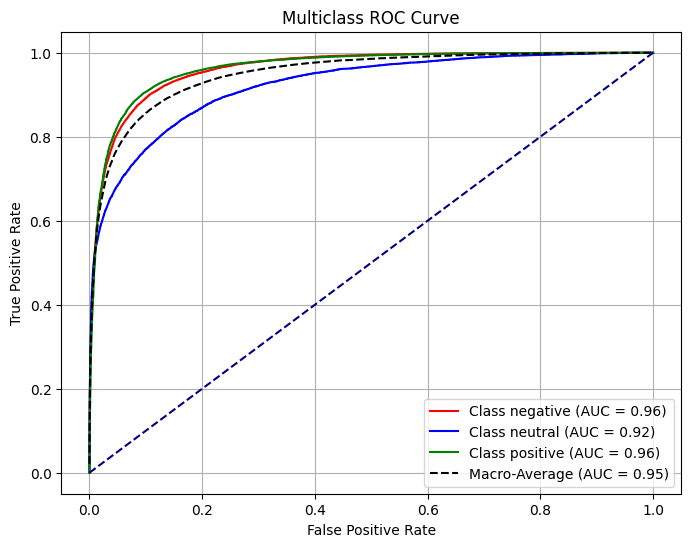

In [52]:
evaluate_model(y_test_true, y_test_pred, model_name="Causal Transformer (Test)", y_proba=test_probs, labels=labels)
plot_auc_curve(y_test_true, test_probs, class_labels=labels)

### **Empirical Tuning**

#### **Checking if the model is overfitting**

In [53]:
train_metrics = model.evaluate(X_train, y_train, verbose=0)
val_metrics = model.evaluate(X_val, y_val, verbose=0)
test_metrics = model.evaluate(X_test, y_test, verbose=0)

print("Train loss/accuracy:", train_metrics)
print("Validation loss/accuracy:", val_metrics)
print("Test loss/accuracy:", test_metrics)


Train loss/accuracy: [0.33303481340408325, 0.8772844076156616]
Validation loss/accuracy: [0.38132748007774353, 0.8585789799690247]
Test loss/accuracy: [0.3834232687950134, 0.8580916523933411]


Since, there is not much difference between the train accuracy and the validation / test accuracy, the model is **not overfitting**.

Plotting **training and validation accuracy** as per epoch

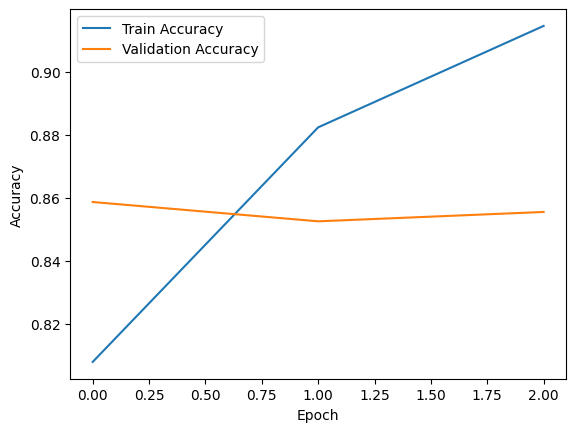

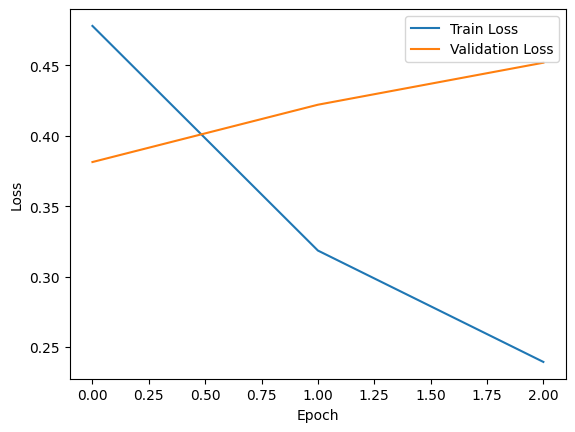

In [54]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


#### **Performance across classes**

For the Positive class, it has excellent performance (very high precision and recall).

For the Negative class, it has strong, balanced performance (precision and recall both 0.79).

For the Neutral class, Recall is good (0.75) and the model finds most of the neutral tweets. However, Precision is much lower (0.61) which implies many tweets predicted as neutral are actually positive or negative. As a result, it implies having a higher false positive rate for neutral class.

#### **AUC vs Accuracy**

In [55]:
from sklearn.metrics import accuracy_score, roc_auc_score

# If your y_test is one-hot and you have test_probs from model.predict:
y_test_true = np.argmax(y_test, axis=1)
y_test_pred = np.argmax(test_probs, axis=1)

# Compute Accuracy
acc = accuracy_score(y_test_true, y_test_pred)
print(f"Test Accuracy: {acc:.4f}")

# Compute Macro AUC (multiclass)
# roc_auc_score needs one-hot ground truth and probability predictions
try:
    macro_auc = roc_auc_score(y_test, test_probs, multi_class="ovr", average="macro")
    print(f"Test Macro AUC: {macro_auc:.4f}")
except Exception as e:
    print("AUC could not be computed for this data shape.", e)


Test Accuracy: 0.8581
Test Macro AUC: 0.9494


Test Accuracy: 0.8581 implies that the model correctly predicts the sentiment for ~86% of the tweets.

Test Macro AUC: 0.9494 implies that the model has a very high ability to rank/score all classes correctly (not just the majority class).As a result, the model is not just memorizing the “positive” class, it is good at distinguishing between all three classes (positive, negative, neutral).

#### **Performance across tweet length**

In [ ]:
test_df_eval = X_test_df.copy()
test_df_eval['true_label'] = y_test_true
test_df_eval['pred_label'] = y_test_pred
test_df_eval['correct'] = (test_df_eval['true_label'] == test_df_eval['pred_label']).astype(int)

In [ ]:
test_df_eval['true_label_str'] = [labels[i] for i in y_test_true]
test_df_eval['pred_label_str'] = [labels[i] for i in y_test_pred]

In [ ]:
bins = [0, 20, 40, 60, 80, 100, 200, 1000]
labels_bins = ['0-20', '21-40', '41-60', '61-80', '81-100', '101-200', '201+']
test_df_eval['length_bin'] = pd.cut(test_df_eval['tweet_length'], bins=bins, labels=labels_bins, right=True)

In [ ]:
length_bin_perf = test_df_eval.groupby('length_bin')['correct'].mean().reset_index()
length_bin_perf.columns = ['Tweet Length Bin', 'Accuracy']

print(length_bin_perf)

  Tweet Length Bin  Accuracy
0             0-20  1.000000
1            21-40  0.954155
2            41-60  0.956342
3            61-80  0.923952
4           81-100  0.930608
5          101-200  0.888666
6             201+  0.784875


C:\Users\User\AppData\Local\Temp\ipykernel_24252\1673452273.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_bin_perf = test_df_eval.groupby('length_bin')['correct'].mean().reset_index()


Plot for **Model Accuracy vs Tweet length**

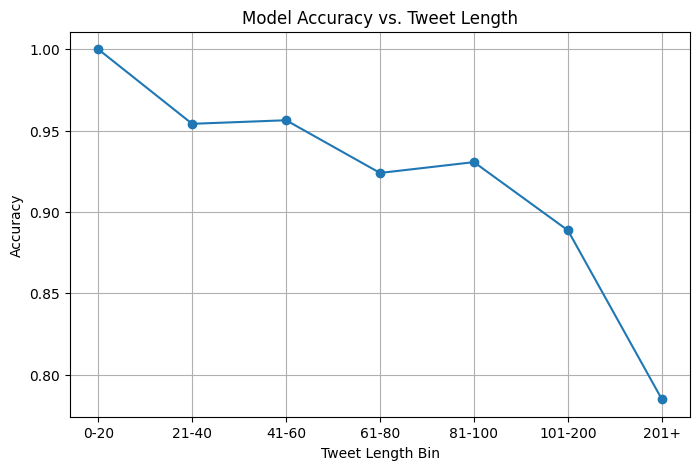

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(length_bin_perf['Tweet Length Bin'], length_bin_perf['Accuracy'], marker='o')
plt.title("Model Accuracy vs. Tweet Length")
plt.xlabel("Tweet Length Bin")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

#### **Tuning Iteration 1: Increasing Neutral Class Weight**

In [ ]:
y_train_int = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
# Manually increase neutral's weight (assuming it's class 1, update index if not)
class_weights[1] *= 1.2   # e.g., increase by 20%
class_weight_dict = dict(enumerate(class_weights))
print("Class weights (with increased neutral):", class_weight_dict)

Class weights (with increased neutral): {0: 1.0, 1: 1.2, 2: 1.0}


In [70]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=10,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    class_weight=class_weight_dict
)

Epoch 1/10
4184/4184 ━━━━━━━━━━━━━━━━━━━━ 1527s 365ms/step - accuracy: 0.8744 - loss: 0.3612 - val_accuracy: 0.8524 - val_loss: 0.4397
Epoch 2/10
4184/4184 ━━━━━━━━━━━━━━━━━━━━ 1240s 296ms/step - accuracy: 0.9117 - loss: 0.2624 - val_accuracy: 0.8618 - val_loss: 0.4457
Epoch 3/10
4184/4184 ━━━━━━━━━━━━━━━━━━━━ 1183s 283ms/step - accuracy: 0.9340 - loss: 0.2020 - val_accuracy: 0.8510 - val_loss: 0.5098


Saving the **1st iteration of tuning model**

In [77]:
model.save('../Models/causal_tf_fasttext_model_tuned_one.h5')

with open('../Models/ctfft_history_tuned_one.pkl', 'wb') as f:
    pickle.dump(history.history, f)

Predicting on **testing set**

In [71]:
test_probs_tuned_one = model.predict(X_test)
y_test_pred_tuned_one = np.argmax(test_probs_tuned_one, axis=1)
y_test_true_tuned_one = np.argmax(y_test, axis=1)

2758/2758 ━━━━━━━━━━━━━━━━━━━━ 73s 27ms/step


Performance metrics, Confusion matrix and ROC curve for **testing set** after **1st iteration of tuning**


Performance Metrics for Causal Transformer tuned by increasing neutral class weight (Test):
Accuracy     : 0.8522
Precision    : 0.8679
Recall       : 0.8522
F1 Score     : 0.8577

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.77      0.77     15314
     neutral       0.60      0.77      0.67     13427
    positive       0.96      0.89      0.92     59492

    accuracy                           0.85     88233
   macro avg       0.77      0.81      0.79     88233
weighted avg       0.87      0.85      0.86     88233



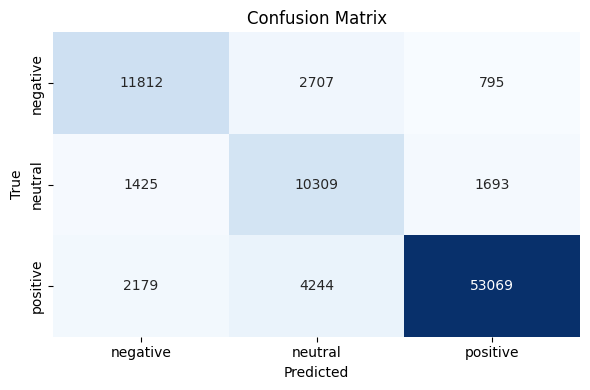

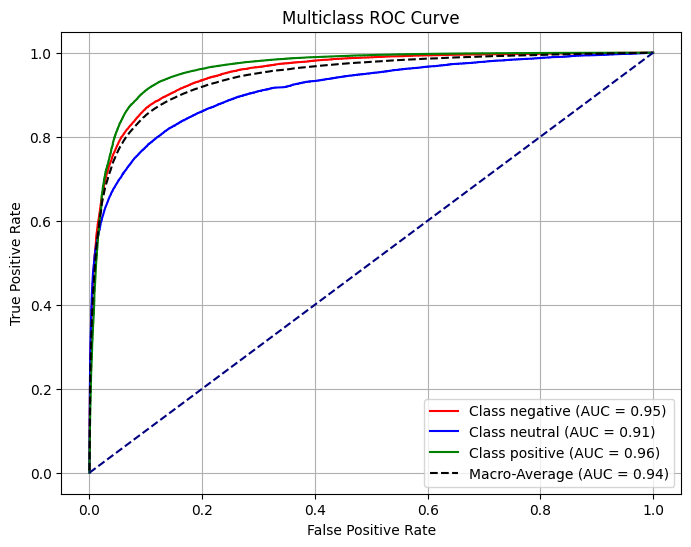

In [72]:
evaluate_model(y_test_true_tuned_one, y_test_pred_tuned_one, model_name="Causal Transformer tuned by increasing neutral class weight (Test)", labels=labels)
plot_auc_curve(y_test_true_tuned_one, test_probs_tuned_one, class_labels=labels)

#### **Tuning iteration 2: Increasing max_len for longer tweets**

Tokenizing with **max_len = 100**

In [78]:
max_len = 100

# 2. Re-pad all splits with new max_len
X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_df['clean_tweet']), maxlen=max_len, padding='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(X_val_df['clean_tweet']),   maxlen=max_len, padding='post')
X_test  = pad_sequences(tokenizer.texts_to_sequences(X_test_df['clean_tweet']),  maxlen=max_len, padding='post')

Building the transformer model

In [79]:
model_tuned_two = build_causal_transformer(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    max_len=max_len,
    num_heads=4,
    ff_dim=embed_dim,
    num_classes=num_classes,
    embedding_matrix=embedding_matrix,
    num_layers=2,
    dropout=0.2,
)

model_tuned_two.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

c:\Users\User\anaconda3\envs\health_risk_model\lib\site-packages\keras\src\layers\layer.py:932: UserWarning: Layer 'causal_mha_with_rel_pos_4' (of type CausalMHAWithRelPos) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Fitting the model

In [80]:
history_tuned_two = model_tuned_two.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=128,
    epochs=5,
    callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
    class_weight=class_weight_dict
)

Epoch 1/5
4184/4184 ━━━━━━━━━━━━━━━━━━━━ 2517s 600ms/step - accuracy: 0.7510 - loss: 0.6340 - val_accuracy: 0.8406 - val_loss: 0.4164
Epoch 2/5
4184/4184 ━━━━━━━━━━━━━━━━━━━━ 2627s 628ms/step - accuracy: 0.8732 - loss: 0.3586 - val_accuracy: 0.8470 - val_loss: 0.4328
Epoch 3/5
4184/4184 ━━━━━━━━━━━━━━━━━━━━ 2671s 638ms/step - accuracy: 0.9112 - loss: 0.2616 - val_accuracy: 0.8536 - val_loss: 0.4685


Saving the **2nd iteration of model tuning**

In [81]:
model_tuned_two.save('../Models/causal_tf_fasttext_model_tuned_two.h5')

with open('../Models/ctfft_history_tuned_two.pkl', 'wb') as f:
    pickle.dump(history.history, f)

Predicting on **testing set**

In [84]:
test_probs_tuned_two = model_tuned_two.predict(X_test)
y_test_pred_tuned_two = np.argmax(test_probs_tuned_two, axis=1)
y_test_true_tuned_two = np.argmax(y_test, axis=1)

c:\Users\User\anaconda3\envs\health_risk_model\lib\site-packages\keras\src\layers\layer.py:932: UserWarning: Layer 'causal_mha_with_rel_pos_4' (of type CausalMHAWithRelPos) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


2758/2758 ━━━━━━━━━━━━━━━━━━━━ 152s 55ms/step


Performance metrics, Confusion matrix and ROC curve for **testing set** after **2nd iteration of tuning**


Performance Metrics for Causal Transformer tuned by increasing max_len (Test):
Accuracy     : 0.8411
Precision    : 0.8721
Recall       : 0.8411
F1 Score     : 0.8501

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.71      0.77     15314
     neutral       0.53      0.81      0.64     13427
    positive       0.96      0.88      0.92     59492

    accuracy                           0.84     88233
   macro avg       0.78      0.80      0.78     88233
weighted avg       0.87      0.84      0.85     88233



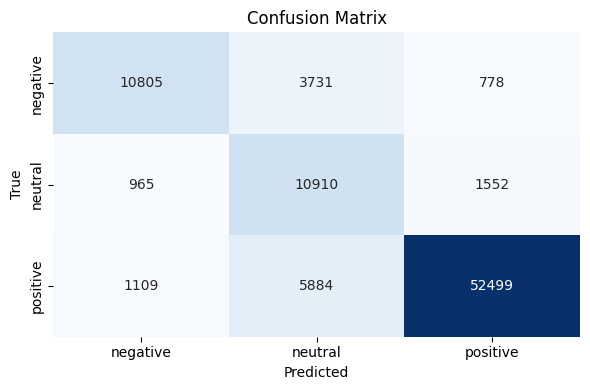

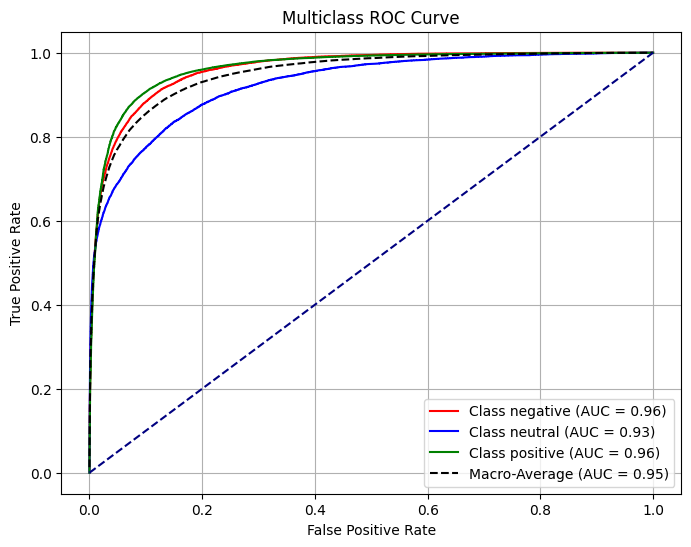

In [85]:
evaluate_model(y_test_true_tuned_two, y_test_pred_tuned_two, model_name="Causal Transformer tuned by increasing max_len (Test)", labels=labels)
plot_auc_curve(y_test_true_tuned_two, test_probs_tuned_two, class_labels=labels)

#### **Performance across tweet length after tuning**

In [ ]:
test_df_eval_tuned = X_test_df.copy()
test_df_eval_tuned['true_label'] = y_test_true_tuned_two
test_df_eval_tuned['pred_label'] = y_test_pred_tuned_two
test_df_eval_tuned['correct'] = (test_df_eval_tuned['true_label'] == test_df_eval_tuned['pred_label']).astype(int)

In [ ]:
test_df_eval_tuned['true_label_str'] = [labels[i] for i in y_test_true_tuned_two]
test_df_eval_tuned['pred_label_str'] = [labels[i] for i in y_test_pred_tuned_two]

In [ ]:
bins = [0, 20, 40, 60, 80, 100, 200, 1000]
labels_bins = ['0-20', '21-40', '41-60', '61-80', '81-100', '101-200', '201+']
test_df_eval_tuned['length_bin'] = pd.cut(test_df_eval_tuned['tweet_length'], bins=bins, labels=labels_bins, right=True)

In [ ]:
length_bin_perf_tuned = test_df_eval_tuned.groupby('length_bin')['correct'].mean().reset_index()
length_bin_perf_tuned.columns = ['Tweet Length Bin', 'Accuracy']

print(length_bin_perf_tuned)

  Tweet Length Bin  Accuracy
0             0-20  1.000000
1            21-40  0.951289
2            41-60  0.952836
3            61-80  0.923752
4           81-100  0.924731
5          101-200  0.879331
6             201+  0.752489


C:\Users\User\AppData\Local\Temp\ipykernel_24252\427207529.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_bin_perf_tuned = test_df_eval_tuned.groupby('length_bin')['correct'].mean().reset_index()


Plot for **Model Accuracy vs Tweet length after tuning**

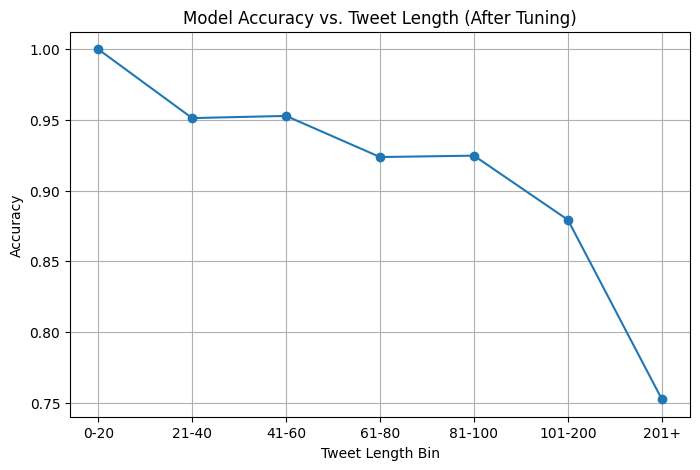

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(length_bin_perf_tuned['Tweet Length Bin'], length_bin_perf_tuned['Accuracy'], marker='o')
plt.title("Model Accuracy vs. Tweet Length (After Tuning)")
plt.xlabel("Tweet Length Bin")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


As a part of empirical tuning, since the precision of the neutral class was less, the model was retrained with updated increased weights for neutral class (1st iteration of empirical tuning).

Also, initially the max_len was set to 50 to reduce the computation time which resulted in long tweet length's accuracy to be less so for the 2nd iteration of empirical tuning, the max_len was set to 100 and the model was retrained which showed some minimal changes in the accuracy for long tweets.

#### **Cross-Validation**

In [93]:
X_cv = np.concatenate([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

# Make sure X_cv is a 2D numpy array, y_cv is one-hot or integer labels
if y_cv.ndim > 1 and y_cv.shape[1] > 1:
    y_cv_int = np.argmax(y_cv, axis=1)
else:
    y_cv_int = y_cv

In [ ]:
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
all_metrics = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv_int), 1):
    print(f"\n===== Fold {fold} =====")
    X_train_fold, X_val_fold = X_cv[train_idx], X_cv[val_idx]
    y_train_fold, y_val_fold = y_cv[train_idx], y_cv[val_idx]
    y_train_int_fold = y_cv_int[train_idx]
    
    # Class weights (increase neutral, update index as needed)
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train_int_fold),
        y=y_train_int_fold
    )
    neutral_idx = np.where(np.array(le.classes_) == "neutral")[0][0]
    class_weights[neutral_idx] *= 1.2
    class_weight_dict = dict(enumerate(class_weights))
    
    # Build and compile model as before
    model = build_causal_transformer(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        max_len=max_len,
        num_heads=4,
        ff_dim=embed_dim,
        num_classes=num_classes,
        embedding_matrix=embedding_matrix,
        num_layers=2,
        dropout=0.2,
    )
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train
    model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        batch_size=128,
        epochs=10,
        callbacks=[keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)],
        class_weight=class_weight_dict,
        verbose=0
    )

    # Evaluate
    val_probs = model.predict(X_val_fold)
    y_val_pred = np.argmax(val_probs, axis=1)
    y_val_true = np.argmax(y_val_fold, axis=1)
    acc = accuracy_score(y_val_true, y_val_pred)
    macro_f1 = f1_score(y_val_true, y_val_pred, average="macro")
    weighted_f1 = f1_score(y_val_true, y_val_pred, average="weighted")
    report = classification_report(y_val_true, y_val_pred, output_dict=True, target_names=list(le.classes_))
    print(f"Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}")

    result = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "neutral_f1": report["neutral"]["f1-score"],
        "positive_f1": report["positive"]["f1-score"],
        "negative_f1": report["negative"]["f1-score"],
    }
    all_metrics.append(result)


===== Fold 1 =====


c:\Users\User\anaconda3\envs\health_risk_model\lib\site-packages\keras\src\layers\layer.py:932: UserWarning: Layer 'causal_mha_with_rel_pos_6' (of type CausalMHAWithRelPos) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [ ]:
metrics_df = pd.DataFrame(all_metrics)
print("\n==== Cross-Validation Summary ====")
print(metrics_df.mean().to_frame("Mean"))
print(metrics_df.std().to_frame("StdDev"))